# Neural Network for ECG Classification



all lead ecg ml with resnet model



#### IMPORTS

In [1]:
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from selfeeg.models import ResNet1D


In [2]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [3]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [4]:
os.chdir("data_prep")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/data_prep'

In [5]:
# get list of all files in the directory
files = os.listdir()
print(files)

['README.md', 'data_prep.ipynb', 'EXPERIMENT_resnet', 'README copy', 'data_prep_for_only_one_disease.ipynb', 'unq_disease_SB.npy', 'disease_SB.npy', 'unq_disease_ST.npy', 'unq_disease_SR.npy', 'disease_ST.npy', 'disease_SR.npy', 'EXPERIMENT_2', 'EXPERIMENT_resnet_1d']


#### LOAD DATA

In [6]:
data_ST_list = np.load("disease_ST.npy")
data_SB_list = np.load("disease_SB.npy")
data_SR_list = np.load("disease_SR.npy")
#print shape of all loaded files
print("shape of ST data: ", data_ST_list.shape)
print("shape of SB data: ", data_SB_list.shape)
print("shape of SR data: ", data_SR_list.shape)

shape of ST data:  (5000, 5000, 12)
shape of SB data:  (5000, 5000, 12)
shape of SR data:  (5000, 5000, 12)


### sanity check

In [7]:
# check the curupted data
def check_data(data):
    corrupted_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any() or np.isinf(data[i]).any():
            corrupted_indices.append(i)
    return corrupted_indices
corrupted_ST = check_data(data_ST_list)
corrupted_SB = check_data(data_SB_list)
corrupted_SR = check_data(data_SR_list)
print("corrupted ST indices: ", corrupted_ST)
print("corrupted SB indices: ", corrupted_SB)
print("corrupted SR indices: ", corrupted_SR)


corrupted ST indices:  [2341, 3205, 3257, 3746, 3810, 3837, 3928, 4232, 4302, 4317, 4516, 4533, 4578]
corrupted SB indices:  [3941, 4202, 4212, 4271]
corrupted SR indices:  [1854, 2166, 2256, 2833, 2888, 3212, 3375, 3749, 3817, 3820, 4083, 4236, 4253, 4425, 4875, 4896]


In [8]:
len(corrupted_SR)

16

In [9]:
# now che ck nana and inf difrently
def check_nan_inf(data):
    nan_indices = []
    inf_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any():
            nan_indices.append(i)
        if np.isinf(data[i]).any():
            inf_indices.append(i)
    return nan_indices, inf_indices
nan_ST, inf_ST = check_nan_inf(data_ST_list)
nan_SB, inf_SB = check_nan_inf(data_SB_list)
nan_SR, inf_SR = check_nan_inf(data_SR_list)
print("NaN ST indices: ", nan_ST)
print("Inf ST indices: ", inf_ST)
print("NaN SB indices: ", nan_SB)
print("Inf SB indices: ", inf_SB)
print("NaN SR indices: ", nan_SR)
print("Inf SR indices: ", inf_SR)


NaN ST indices:  [2341, 3205, 3257, 3746, 3810, 3837, 3928, 4232, 4302, 4317, 4516, 4533, 4578]
Inf ST indices:  []
NaN SB indices:  [3941, 4202, 4212, 4271]
Inf SB indices:  []
NaN SR indices:  [1854, 2166, 2256, 2833, 2888, 3212, 3375, 3749, 3817, 3820, 4083, 4236, 4253, 4425, 4875, 4896]
Inf SR indices:  []


In [10]:
# Loop over all ST indices with NaNs and summarize locations
nan_summary = {}

for idx in nan_ST:
    sample = data_ST_list[idx]  # shape: (5000, 12)

    # All NaN locations for this sample
    locs = np.argwhere(np.isnan(sample))  # rows, cols
    cols_with_nan = np.unique(locs[:, 1]) if locs.size else np.array([], dtype=int)



    nan_summary[idx] = {
        "count": int(locs.shape[0]),
        "cols": cols_with_nan.tolist()
,
    }

    print(
        f"ST sample {idx}: NaNs={nan_summary[idx]['count']}, "
        f"cols={nan_summary[idx]['cols']}, "
    )

# Optional: access detailed rows for a given sample index, e.g., nan_summary[nan_ST[0]]["rows_in_col"]

ST sample 2341: NaNs=31, cols=[9, 10], 
ST sample 3205: NaNs=26, cols=[11], 
ST sample 3257: NaNs=26, cols=[11], 
ST sample 3746: NaNs=3, cols=[8], 
ST sample 3810: NaNs=64, cols=[7], 
ST sample 3837: NaNs=12, cols=[11], 
ST sample 3928: NaNs=21, cols=[11], 
ST sample 4232: NaNs=3, cols=[11], 
ST sample 4302: NaNs=57, cols=[11], 
ST sample 4317: NaNs=213, cols=[9, 10, 11], 
ST sample 4516: NaNs=68, cols=[8], 
ST sample 4533: NaNs=3, cols=[9], 
ST sample 4578: NaNs=422, cols=[7, 10], 


In [11]:
import numpy as np

# Get the array
data = data_ST_list[nan_ST[-2]]
print(f"Array shape: {data.shape}")

# Find exact NaN locations
nan_locations = np.argwhere(np.isnan(data))

print(f"\nTotal NaN values found: {len(nan_locations)}")
print("\nNaN locations (row, column):")
for row, col in nan_locations:
    print(f"  NaN at row {row}, column {col}")

Array shape: (5000, 12)

Total NaN values found: 3

NaN locations (row, column):
  NaN at row 707, column 9
  NaN at row 723, column 9
  NaN at row 724, column 9


In [12]:
# import numpy as np

# datasets = {
#     "ST": (data_ST_list, nan_ST),
#     "SR": (data_SR_list, nan_SR),
#     "SB": (data_SB_list, nan_SB),
# }

# nan_summary = {}

# for name, (data_list, nan_indices) in datasets.items():
#     for idx in nan_indices:
#         sample = data_list[idx]  # shape: (5000, 12)

#         # All NaN locations
#         locs = np.argwhere(np.isnan(sample))  # (row, col)
#         cols_with_nan = np.unique(locs[:, 1]) if locs.size else np.array([], dtype=int)


#         nan_summary[(name, idx)] = {
#             "count": int(locs.shape[0]),
#             "cols": cols_with_nan.tolist(),
#         }

#         print(
#             f"{name} sample {idx}: NaNs={nan_summary[(name, idx)]['count']}, "
#             f"cols={nan_summary[(name, idx)]['cols']}, "
#         )


In [13]:
# remove corrupted data from all three datasets
def remove_corrupted_data(data_list, corrupted_indices):
    return np.delete(data_list, corrupted_indices, axis=0)
    return cleaned_data

data_ST_list = remove_corrupted_data(data_ST_list, nan_ST + inf_ST)
data_SB_list = remove_corrupted_data(data_SB_list, nan_SB + inf_SB)
data_SR_list = remove_corrupted_data(data_SR_list, nan_SR + inf_SR)

### creating batches


In [14]:

# lead 1
# Use ALL 12 leads
images = data_ST_list          # shape: (N_ST, T, 12)
labels = np.zeros(images.shape[0])

# SB
images = np.concatenate((images, data_SB_list), axis=0)
labels = np.concatenate((labels, np.ones(data_SB_list.shape[0])))

# SR
images = np.concatenate((images, data_SR_list), axis=0)
labels = np.concatenate((labels, 2*np.ones(data_SR_list.shape[0])))

print("we have", images.shape[0], "samples and", labels.shape[0], "labels")
print("raw shape:", images.shape)

                    

we have 14967 samples and 14967 labels
raw shape: (14967, 5000, 12)


In [15]:
len(images),len(labels)

(14967, 14967)

In [16]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 5000, 12)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [17]:
# compute stats on TRAIN set only
mean = X_train.mean(axis=(0, 1))   # (12,)
std  = X_train.std(axis=(0, 1))    # (12,)

std[std < 1e-6] = 1e-6  # safety


In [18]:
# apply normalization
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


#### transposing data

In [19]:
# (batch, time, channels) → (batch, channels, time)
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)


In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

#### CREATE BATCHES


## model


In [21]:
# --- Paper benchmark: 1D ResNet for ECG ---
import torch
import torch.nn as nn

class BenchmarkResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return out


class BenchmarkECGResNet1D(nn.Module):
    def __init__(self, in_channels=12, num_classes=3, base_channels=64, dropout=0.2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(base_channels, base_channels, blocks=2, stride=1)
        self.layer2 = self._make_layer(base_channels, base_channels * 2, blocks=2, stride=2)
        self.layer3 = self._make_layer(base_channels * 2, base_channels * 4, blocks=2, stride=2)
        self.layer4 = self._make_layer(base_channels * 4, base_channels * 8, blocks=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(base_channels * 8, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = [BenchmarkResidualBlock1D(in_channels, out_channels, stride=stride)]
        for _ in range(1, blocks):
            layers.append(BenchmarkResidualBlock1D(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.classifier(x)


# Example usage for your benchmark experiments
benchmark_model_1d = BenchmarkECGResNet1D(in_channels=12, num_classes=3)
print(benchmark_model_1d.__class__.__name__)

BenchmarkECGResNet1D


In [22]:
default_directory()
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
import importlib, plots
importlib.reload(plots)
from plots import evaluate_all
from seed_utils import set_seed, SEEDS


# ── 1. Setup multi-seed tracking ──
all_metrics = []
all_histories = []

log_dir = "EXPERIMENT_resnet_1d_selfeeg_typ2_randomseed"
os.makedirs(log_dir, exist_ok=True)

# Try getting notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "main__resnet_1d_selfeeg_typ2"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

# ── 2. Loop through seeds ──
for seed in SEEDS:
    namkaran = f"resnet_1d_selfeeg_lr1e-3_seed{seed}"
    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")
    
    # Use our seed utility!
    set_seed(seed)

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started for Seed {seed}: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print("="*60, f)

        # Initialize model inside loop to reset weights!
        model = ResNet1D(nb_classes=3, Chans=12, Samples=5000, Layers=[2,2,2,2], inplane=32, kernLength=7).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        def correct(pred, true):
            return (pred == true).sum().item()

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None
        num_epochs, patience = 25, 7
        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            
            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()
            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()
            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]
            
            if lr_now != old_lr:
                log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s", f
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s", f)
        
        # ── 3. Evaluate the seed silently and store results ──
        log_print(f"Evaluating best model on test set for seed {seed}...", f)
        results = evaluate_all(
            model, test_dataloader, device,
            plot_confusion_matrix=False,
            plot_pr_micro=False,
            plot_pr_per_class=False,
            plot_roc=False,
            print_report=False
        )
        all_metrics.append(results)
        
        history = {
            "train_acc": accuracy_train_list,
            "val_acc": accuracy_val_list,
            "train_loss": train_losses_list,
            "val_loss": val_losses_list
        }
        all_histories.append(history)

print("\n ALL 5 SEEDS COMPLETED!")

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN

Training Run Started for Seed 40: 2026-07-02 12:41:54
Epoch [1/25] | Train Loss: 0.3770, Val Loss: 0.3509, Train Acc: 85.90%, Val Acc: 85.26%, LR: 0.001000 | Time: 289.53s
Epoch [2/25] | Train Loss: 0.2127, Val Loss: 0.1809, Train Acc: 92.34%, Val Acc: 94.34%, LR: 0.001000 | Time: 290.41s
Epoch [3/25] | Train Loss: 0.1699, Val Loss: 0.2372, Train Acc: 94.10%, Val Acc: 93.54%, LR: 0.001000 | Time: 290.61s
Epoch [4/25] | Train Loss: 0.1569, Val Loss: 0.1609, Train Acc: 94.69%, Val Acc: 93.45%, LR: 0.001000 | Time: 290.64s
Epoch [5/25] | Train Loss: 0.1592, Val Loss: 0.1534, Train Acc: 94.39%, Val Acc: 94.74%, LR: 0.001000 | Time: 290.63s
Epoch [6/25] | Train Loss: 0.1319, Val Loss: 0.1222, Train Acc: 95.75%, Val Acc: 95.86%, LR: 0.001000 | Time: 290.70s
Epoch [7/25] | Train Loss: 0.1425, Val Loss: 0.1064, Train Acc: 95.10%, Val Acc: 96.26%, LR: 0.001000 | Time: 290.71s
Epoch [8/25] | Train Loss: 0.


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               97.78% ± 0.20%     
  f1_macro               0.9778 ± 0.0020    
  f1_micro               0.9778 ± 0.0020    
  auc_macro              0.9983 ± 0.0002    
  ap_micro               0.9969 ± 0.0004    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9797 ± 0.0030      0.9816 ± 0.0029      0.9806 ± 0.0019      0.9986 ± 0.0002      748.0
  SB              0.9874 ± 0.0024      0.9840 ± 0.0048      0.9857 ± 0.0018      

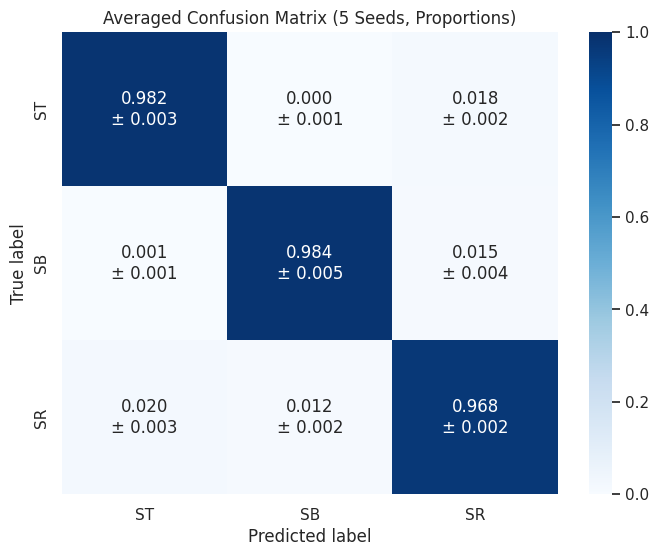

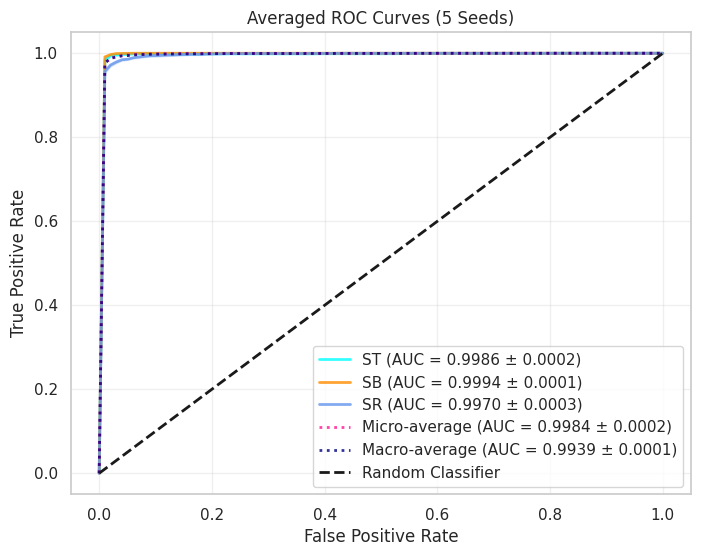

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9986 ± 0.0002
Class SB: 0.9994 ± 0.0001
Class SR: 0.9970 ± 0.0003
Micro-average: 0.9984 ± 0.0002
Macro-average: 0.9939 ± 0.0001
------------------------------



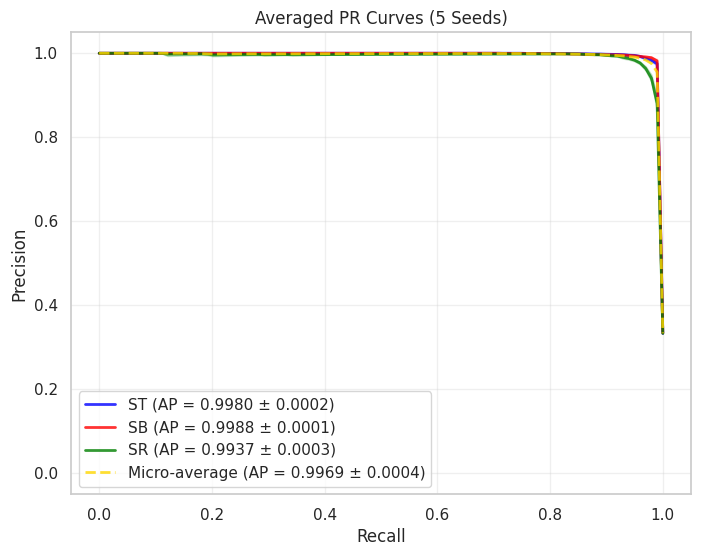

Saved: EXPERIMENT_resnet_1d_selfeeg_typ2_randomseed/resnet_1d_selfeeg_lr1e-3_seed44_val_acc_multiseed.png


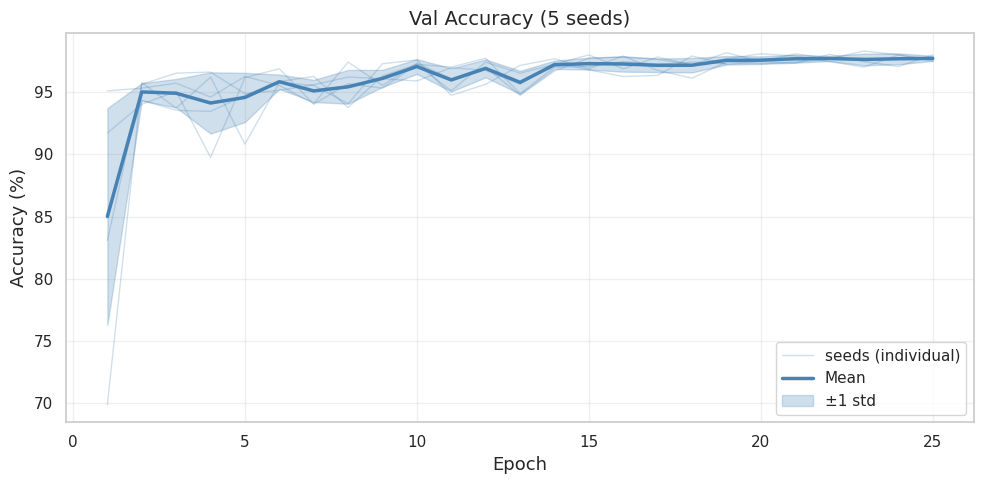

Saved: EXPERIMENT_resnet_1d_selfeeg_typ2_randomseed/resnet_1d_selfeeg_lr1e-3_seed44_val_loss_multiseed.png


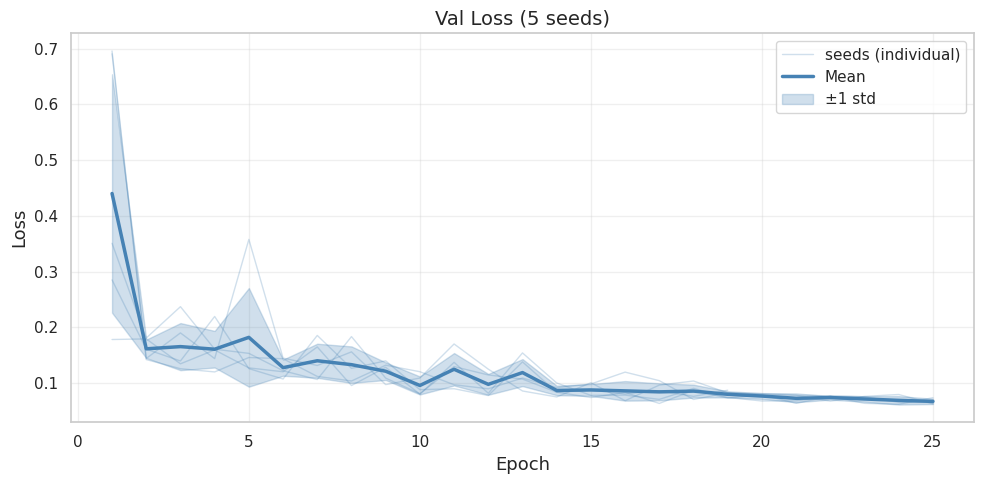

In [23]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)
